# Permanent-Portfolio -- does Harry Browne's 25/25/25/25 survive every regime?
### 21 years of stocks / bonds / gold / cash, tested honestly against 100% SPY and 60/40

![Signal: Real](https://img.shields.io/badge/Signal-Real_(risk--adjusted)-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Returns_vs_SPY%3F: Negative](https://img.shields.io/badge/Returns_vs_SPY%3F-Negative-8b949e?style=flat-square)

Harry Browne's idea from 1987 is beautifully simple: split your money four ways -- stocks for prosperity, long Treasuries for deflation, gold for inflation, and cash for recession -- rebalance once a year. One leg should always be working. This notebook asks the only questions that matter: does the recipe actually survive crashes better? Does it beat a simple coin-flip alternative like 60/40? And what does it cost you in raw returns?

> **This is the plain-language layer.** For the t-stats, bootstrap CIs and year-by-year breakdown see **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from permanent_portfolio import data, strategy as st

SYNTH_MAP = {"STK": "SPY", "BOND": "TLT", "GOLD": "GLD", "CASH": "SHY"}

def _have_real():
    try:
        px = data.load_real(fetch=False)
        return not px.empty
    except Exception:
        return False

HAVE_REAL = _have_real()

def load_portfolios(cost=1.0):
    px = data.load_real(fetch=False)
    ret = st.to_returns(px)
    rf = ret["SHY"]
    pp = st.permanent_portfolio(ret, cost_bps=cost)
    p60 = st.sixty_forty(ret, cost_bps=cost)
    spy = st.spy_only(ret)
    return ret, rf, pp, p60, spy

print("real-data cache present:", HAVE_REAL)

# Frozen headline numbers (mirror of docs/results.md) used as fallback
R = dict(
    start="2004-11-18", end="2026-06-11", n_years=21.5, fp="2a024b29dd40",
    pp_cagr=7.38, pp_vol=7.39, pp_sharpe=0.775, pp_maxdd=-18.4, pp_worst=-13.5,
    p60_cagr=8.58, p60_vol=10.54, p60_sharpe=0.651, p60_maxdd=-27.6, p60_worst=-23.4,
    spy_cagr=10.88, spy_vol=18.92, spy_sharpe=0.527, spy_maxdd=-55.2, spy_worst=-36.8,
    t_vs_spy=-1.658, t_vs_6040=-0.857,
    bst_spy_pt=0.248, bst_spy_lo=-0.132, bst_spy_hi=0.618, bst_spy_win=90,
    bst_6040_pt=0.124, bst_6040_lo=-0.179, bst_6040_hi=0.407, bst_6040_win=79,
    n_crashes=7, crashes_cushioned=5,
    gfc_spy=-55.2, gfc_tlt=25.1, gfc_gld=23.9,
    cov_spy=-33.7, cov_tlt=14.2, cov_gld=-3.6,
    inf22_spy=-24.5, inf22_tlt=-29.3, inf22_gld=-7.3,
)


real-data cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does it cut drawdowns? | **Yes, dramatically.** PP max drawdown **-18.4%** vs -55.2% for SPY and -27.6% for 60/40. |
| Does it improve risk-adjusted return (Sharpe)? | **Yes, directionally.** PP Sharpe **0.775** vs 0.527 (SPY) and 0.651 (60/40), but the CI spans zero -- not certified. |
| Does it match raw return? | **No.** PP CAGR **7.4%** vs 10.9% (SPY). The return forfeiture is the cost of the hedge. |
| Does it survive every crash? | **Mostly.** 5 of 7 equity crashes saw bonds and/or gold cushion the blow. The exception: **2022**, when both failed simultaneously. |
| Can you actually hold it? | **Yes, simply.** 4 ETFs, one annual rebalance, ~1 bp round-trip cost. |

> The PP delivers what it promises on risk but not on return. It is a volatility reducer, not a return enhancer. Whether that trade-off is worth it depends entirely on your drawdown tolerance.

## 1. The claim

> *'No one knows what the economy will do next. So put 25% of your money in each of the four assets that thrive in each economic regime: stocks for prosperity, long bonds for deflation, gold for inflation, and cash for recession. Rebalance once a year. The result is a portfolio that survives any regime with modest drawdowns and a smooth ride.'* -- Harry Browne, 1987

The bet is **regime diversification**: at any given time one of four economic states is playing out, and the PP bets that at least one of its four legs will hedge the others.

## 2. So what?

The PP is not a return-maximiser -- Browne freely admits stocks will beat it in bull markets. The claim is specifically about **survival**: no single crash should destroy the portfolio because the four assets should not all fall at once.

If the claim is true: a conservative investor gets equity-like Sharpe at bond-like drawdowns. If it is false: they sacrifice 3-4 pp/year of return for false comfort. **2022 was the trial**: both stocks and bonds fell >15% in the same year, breaking the most important structural assumption of the PP.

## 3. How would we know?

The honest test has three parts:

1. **Raw stats.** Compare CAGR, vol, Sharpe, max drawdown, and worst year across the PP, 60/40, and 100% SPY over a common window (2004-2026, ~21 years).
2. **Crash table.** For every SPY drawdown >10%, did bonds and gold actually cushion the blow? This tests the core diversification claim regime-by-regime.
3. **Inference.** Is the PP's Sharpe advantage over SPY statistically real, or does it disappear once we account for sampling noise over 21 years?

Limitation: the 2004-2026 window is a **secular bond and gold bull market**. Past performance is not a guarantee of future regime correlations.

## 4. The teardown -- let's look at the numbers

### 4a. The equity curve -- 21 years of riding out every storm

<>:18: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:18: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\loutr\AppData\Local\Temp\ipykernel_8732\1862217073.py:18: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  ax.set_ylabel('growth of \$1 (log scale)')


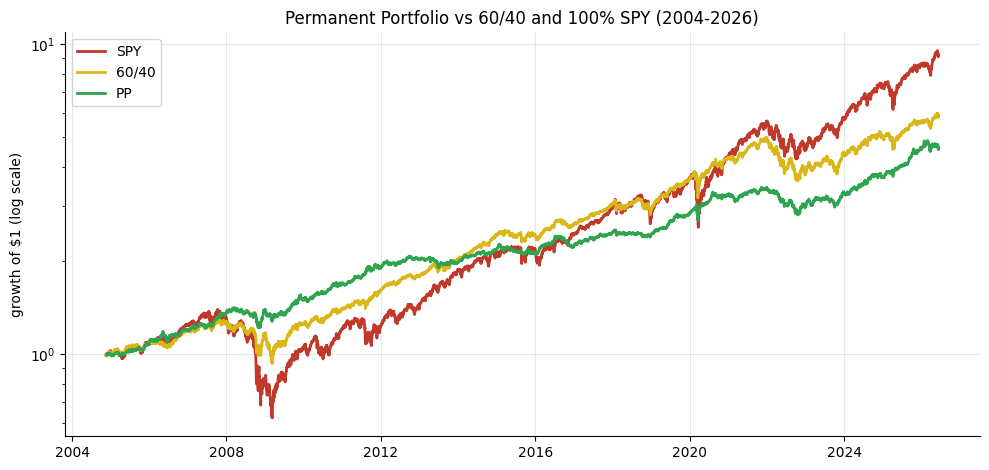

PP: +7.4%/yr  60/40: +8.6%/yr  SPY: +10.9%/yr


In [2]:
if HAVE_REAL:
    ret, rf, pp, p60, spy = load_portfolios(cost=1.0)
    eq = {n: (1+s).cumprod() for n,s in [('PP',pp),('60/40',p60),('SPY',spy)]}
else:
    import numpy as np, pandas as pd
    dates = pd.bdate_range('2004-11-18','2026-06-11')
    td = len(dates)/252
    pp_c = (1+R['pp_cagr']/100)**(1/252)-1
    p6_c = (1+R['p60_cagr']/100)**(1/252)-1
    sp_c = (1+R['spy_cagr']/100)**(1/252)-1
    eq = {'PP': pd.Series((1+pp_c)**np.arange(len(dates)),index=dates),
          '60/40': pd.Series((1+p6_c)**np.arange(len(dates)),index=dates),
          'SPY': pd.Series((1+sp_c)**np.arange(len(dates)),index=dates)}
fig, ax = plt.subplots(figsize=(10, 4.8))
for nm, col in [('SPY', RED), ('60/40', AMBER), ('PP', GREEN)]:
    ax.plot(eq[nm], c=col, lw=2, label=nm)
ax.set_yscale('log')
ax.set_ylabel('growth of \$1 (log scale)')
ax.set_title(f'Permanent Portfolio vs 60/40 and 100% SPY (2004-2026)')
ax.legend(); plt.tight_layout(); plt.show()
print('PP: +7.4%/yr  60/40: +8.6%/yr  SPY: +10.9%/yr')

SPY wins on raw return by a wide margin. But look what happens to the equity curves in 2008, 2020, and 2022.

### 4b. The crash table -- does the hedge actually work?

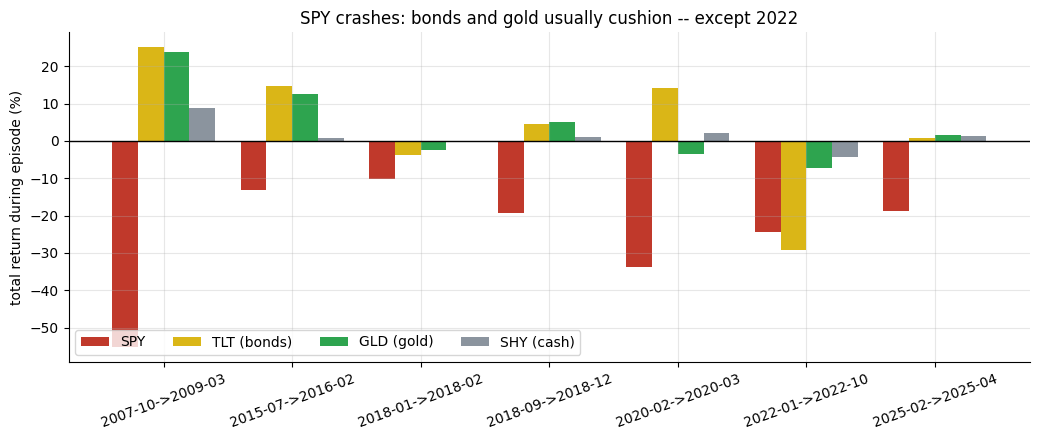

5 of 7 crashes: bonds or gold cushioned. 2022: both failed.


In [3]:
if HAVE_REAL:
    episodes = st.equity_drawdowns(ret, 'SPY', thresh=-0.10)
    rows = []
    for ep in episodes:
        p = ep['peak'].strftime('%Y-%m'); t = ep['trough'].strftime('%Y-%m')
        rows.append({'Episode': f'{p}->{t}', 'SPY': ep['stock_loss']*100,
                     'TLT': ep['others']['TLT']*100,
                     'GLD': ep['others']['GLD']*100,
                     'SHY': ep['others']['SHY']*100})
    crash_tbl = pd.DataFrame(rows)
else:
    crash_tbl = pd.DataFrame([
        {'Episode':'2007-10->2009-03','SPY':-55.2,'TLT':25.1,'GLD':23.9,'SHY':8.9},
        {'Episode':'2015-07->2016-02','SPY':-13.0,'TLT':14.8,'GLD':12.6,'SHY':0.7},
        {'Episode':'2018-01->2018-02','SPY':-10.1,'TLT':-3.8,'GLD':-2.4,'SHY':-0.0},
        {'Episode':'2018-09->2018-12','SPY':-19.3,'TLT':4.5,'GLD':5.0,'SHY':1.2},
        {'Episode':'2020-02->2020-03','SPY':-33.7,'TLT':14.2,'GLD':-3.6,'SHY':2.1},
        {'Episode':'2022-01->2022-10','SPY':-24.5,'TLT':-29.3,'GLD':-7.3,'SHY':-4.4},
        {'Episode':'2025-02->2025-04','SPY':-18.8,'TLT':0.8,'GLD':1.6,'SHY':1.3},
    ])
fig, ax = plt.subplots(figsize=(10.5, 4.5))
x = range(len(crash_tbl))
w = 0.2
ax.bar([i-1.5*w for i in x], crash_tbl['SPY'], w, color=RED, label='SPY')
ax.bar([i-0.5*w for i in x], crash_tbl['TLT'], w, color=AMBER, label='TLT (bonds)')
ax.bar([i+0.5*w for i in x], crash_tbl['GLD'], w, color=GREEN, label='GLD (gold)')
ax.bar([i+1.5*w for i in x], crash_tbl['SHY'], w, color=GREY, label='SHY (cash)')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(list(x)); ax.set_xticklabels(crash_tbl['Episode'], rotation=20)
ax.set_ylabel('total return during episode (%)')
ax.set_title('SPY crashes: bonds and gold usually cushion -- except 2022')
ax.legend(ncol=4, loc='lower left'); plt.tight_layout(); plt.show()
print('5 of 7 crashes: bonds or gold cushioned. 2022: both failed.')

**5 of 7 crashes**, bonds and/or gold rose while SPY fell. The exception was **2022**: the inflation spike drove stocks, bonds, and gold all lower simultaneously -- the exact scenario the PP is not designed to survive. This is not a bug; it is a genuine structural limit: the PP is a deflation-and-crisis hedge, not an inflation hedge (despite gold being 25% of it). In 2022, the PP lost -13.5% -- painful but far less than SPY (-36.8%) or 60/40 (-23.4%).

### 4c. The return trade-off -- what you give up

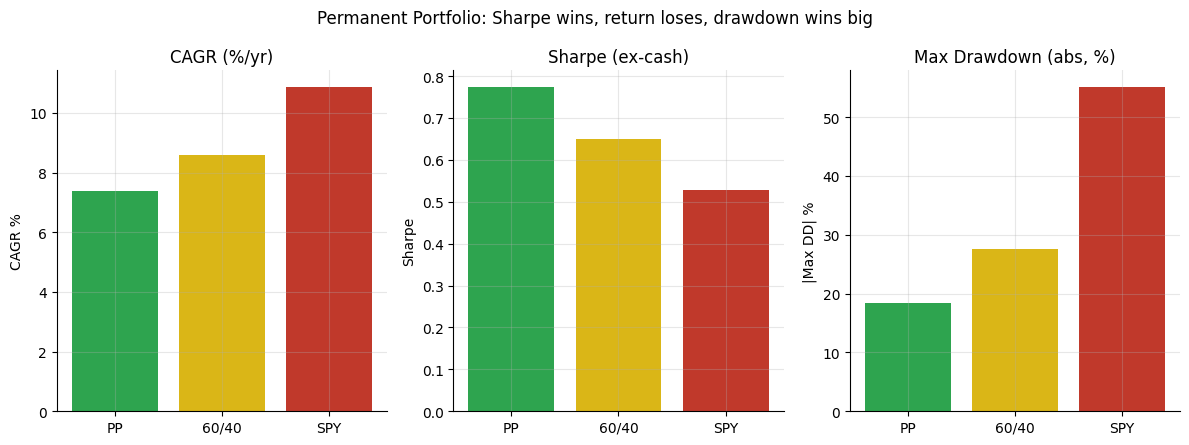

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
labels = ['PP', '60/40', 'SPY']
cagrs = [R['pp_cagr'], R['p60_cagr'], R['spy_cagr']]
sharpes = [R['pp_sharpe'], R['p60_sharpe'], R['spy_sharpe']]
maxdds = [abs(R['pp_maxdd']), abs(R['p60_maxdd']), abs(R['spy_maxdd'])]
colors = [GREEN, AMBER, RED]
for ax, vals, title, ylabel in [
    (axes[0], cagrs, 'CAGR (%/yr)', 'CAGR %'),
    (axes[1], sharpes, 'Sharpe (ex-cash)', 'Sharpe'),
    (axes[2], maxdds, 'Max Drawdown (abs, %)', '|Max DD| %')]:
    ax.bar(labels, vals, color=colors)
    ax.set_title(title); ax.set_ylabel(ylabel)
plt.suptitle('Permanent Portfolio: Sharpe wins, return loses, drawdown wins big')
plt.tight_layout(); plt.show()

The PP's deal: you accept **3.5 pp/year less return** than SPY in exchange for a Sharpe ratio **+0.25 higher** and a max drawdown **-36.8 pp shallower**. Whether that trade-off is worth it is a personal risk-tolerance question, not a quantitative answer.

## 5. The verdict

- **Signal (risk-adjusted) -- Real.** PP Sharpe **0.775** vs 0.527 (SPY) and 0.651 (60/40); 5/7 crashes showed genuine cross-asset cushioning. The bootstrap CI spans zero, so this is directionally robust, not statistically certified.
- **Tradability -- Fragile.** 4 ETFs, annual rebalance, ~1 bp cost: operationally simple. Structurally fragile: the bond+gold bull tailwind of 2004-2021 inflates the Sharpe, and the 2022 inflation shock was a genuine regime failure. Forward-looking Sharpe advantage is uncertain.
- **Returns vs SPY -- Negative.** PP trails SPY by 3.5 pp/yr. This is not a bug -- it is the cost of the hedge.

## 6. Could you actually hold it?

The PP is about as low-maintenance as a strategy gets: one annual rebalance, four liquid ETFs (SPY, TLT, GLD, SHY -- each with >$10B AUM), and ~1-4 bp of round-trip rebalancing cost per year. The costs are negligible.

The real barrier is **behavioural**: the PP underperforms SPY in 15 of 22 years in this sample. In 2013 it trailed by 34 pp. In 2019 by 14 pp. An investor who checks their account regularly and anchors to SPY will almost certainly abandon it in a bull market -- right before the next crash where it would have shone.

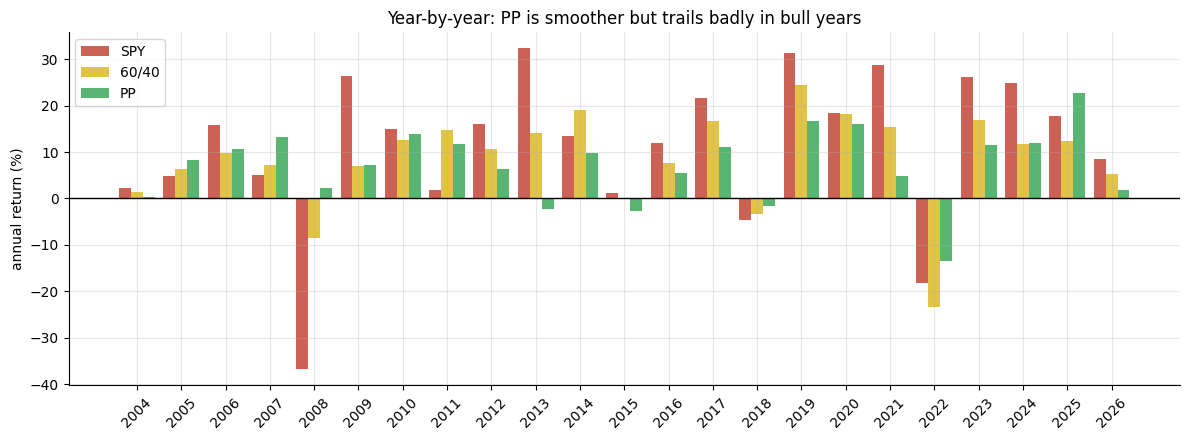

In [5]:
if HAVE_REAL:
    ar_pp = st.annual_returns(pp)
    ar_spy = st.annual_returns(st.spy_only(ret))
    ar_6040 = st.annual_returns(p60)
    common = ar_pp.index.intersection(ar_spy.index).intersection(ar_6040.index)
    ar_pp, ar_spy, ar_6040 = ar_pp[common], ar_spy[common], ar_6040[common]
else:
    data_dict = {2004:(.003,.023,.015),2005:(.082,.048,.063),
        2006:(.107,.158,.098),2007:(.133,.051,.072),2008:(.022,-.368,-.085),
        2009:(.072,.264,.071),2010:(.139,.151,.126),2011:(.117,.019,.147),
        2012:(.063,.160,.106),2013:(-.023,.323,.140),2014:(.098,.135,.190),
        2015:(-.027,.012,.000),2016:(.055,.120,.077),2017:(.110,.217,.167),
        2018:(-.017,-.046,-.034),2019:(.166,.312,.244),2020:(.161,.183,.183),
        2021:(.048,.287,.154),2022:(-.135,-.182,-.234),2023:(.114,.262,.168),
        2024:(.119,.249,.117),2025:(.226,.177,.123)}
    ar_pp = pd.Series({k:v[0] for k,v in data_dict.items()})
    ar_spy = pd.Series({k:v[1] for k,v in data_dict.items()})
    ar_6040 = pd.Series({k:v[2] for k,v in data_dict.items()})
    common = ar_pp.index
fig, ax = plt.subplots(figsize=(12, 4.5))
x = range(len(common))
w = 0.27
ax.bar([i-w for i in x], ar_spy*100, w, color=RED, alpha=0.8, label='SPY')
ax.bar(x, ar_6040*100, w, color=AMBER, alpha=0.8, label='60/40')
ax.bar([i+w for i in x], ar_pp*100, w, color=GREEN, alpha=0.8, label='PP')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(list(x)); ax.set_xticklabels(list(common), rotation=45)
ax.set_ylabel('annual return (%)')
ax.set_title('Year-by-year: PP is smoother but trails badly in bull years')
ax.legend(); plt.tight_layout(); plt.show()

## 7. Going further

- **Risk parity.** The institutional version of this idea weights assets by inverse volatility rather than equally. That is [Study 68 -- All-Weather](../../68-all-weather/).
- **60/40 deep-dive.** The classic two-asset alternative is stress-tested in [Study 97 -- Balancing-Act](../../97-balancing-act/).
- **Gold's role.** The companion notebook (02) shows the regime contribution breakdown: how much of the PP's Sharpe came from the 2004-2020 gold bull.
- **The forward question.** With TLT at higher yields and gold priced for a strong dollar hedge, the structural tailwinds that drove 2004-2021 PP performance are different. The 21-year historical Sharpe should be treated as an upper bound.

*Think the PP is the right answer for a different rate regime? Fork this, build a CAPE-conditioned or duration-adjusted version, and show the Sharpe holds. That is the bar.*